In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('Data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


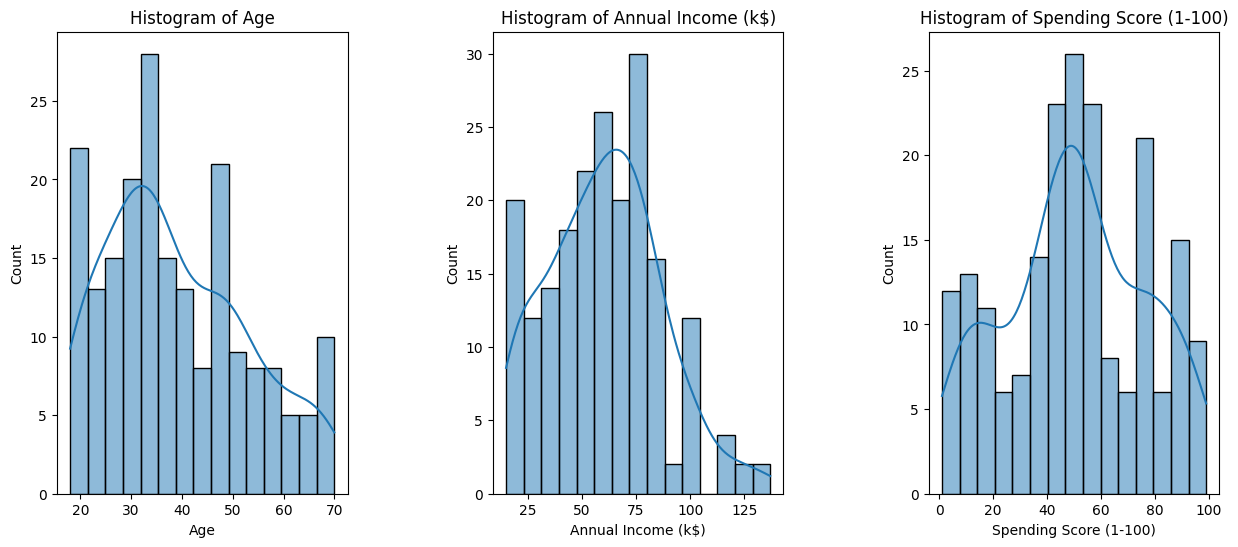

In [6]:
plt.figure(1 , figsize = (15 , 6))
i=1
for x in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    plt.subplot(1 , 3 , i)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.histplot(df[x] , bins = 15, kde=True)
    plt.title('Histogram of {}'.format(x))
    i = i+1
plt.show()

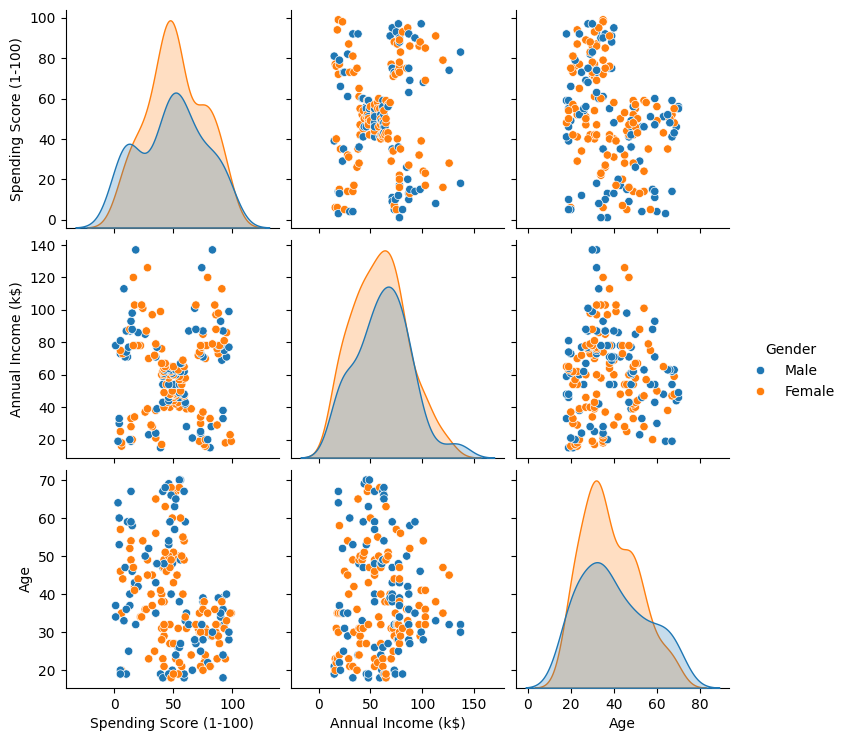

In [7]:
sns.pairplot(df, vars = ['Spending Score (1-100)', 'Annual Income (k$)', 'Age'], hue = "Gender")

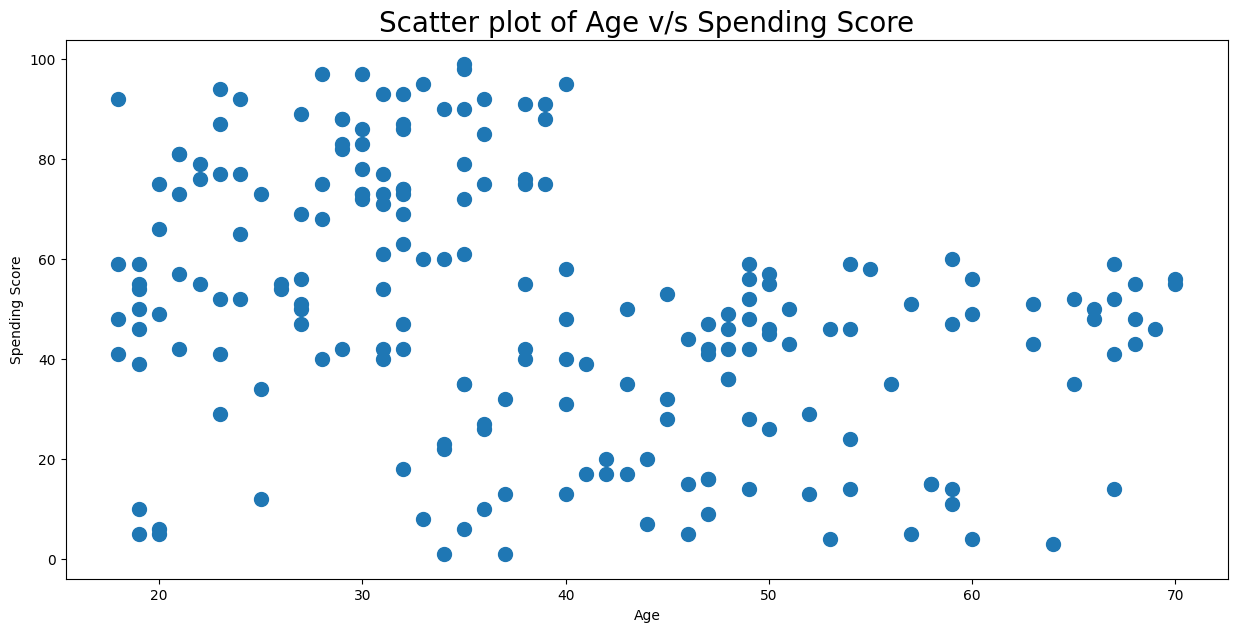

In [8]:
plt.figure(1 , figsize = (15 , 7))
plt.title('Scatter plot of Age v/s Spending Score', fontsize = 20)
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.scatter( x = 'Age', y = 'Spending Score (1-100)', data = df, s = 100)
plt.show()

In [9]:
X1 = df.drop(columns = ["Gender", "CustomerID", "Annual Income (k$)"], axis=1)
s = StandardScaler()
X1_scaled = s.fit_transform(X1)

k_range = range(3, 15)
inertia = []
sil_scores = []

for n in k_range:
    km = KMeans(n_clusters=n, init='k-means++', n_init=10, max_iter=300, 
                tol=0.0001, random_state=111, algorithm='lloyd')
    labels = km.fit_predict(X1_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X1_scaled, labels))

### k-means++ is a smart initialization. It picks the first centroid at random and then picks the other centroids as far as possible. from the ones already chosen.
### n_init tells the computer to run the entire clustering process 10 different times using 10 different starting seeds. At the end, Scikit-Learn will automatically keep only the best result (the one with the lowest Inertia).
### tol K-Means is an iterative "dance"—the centroids move, the points re-assign, and the centroids move again.(Tolerance) tells the algorithm when to stop. It measures the change in Inertia between one step and the next. If the change is smaller than 0.0001, the computer decides: "The centers haven't moved enough to matter anymore, I'm done."
### max_iter You didn't ask, but it's related to tol. If for some reason the algorithm keeps moving and doesn't hit that tol limit, max_iter tells it: "Even if you aren't perfectly finished, stop after 300 moves." It’s a safety limit to prevent an infinite loop.

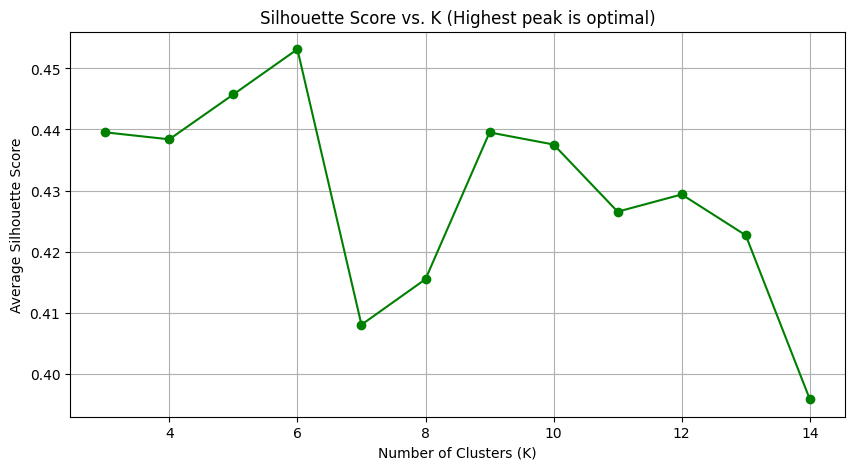

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, sil_scores, marker='o', color='green')
plt.title('Silhouette Score vs. K (Highest peak is optimal)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

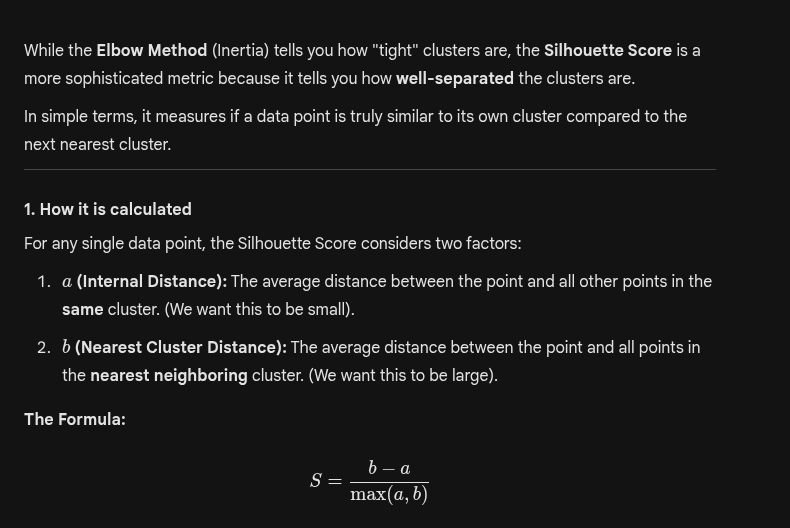

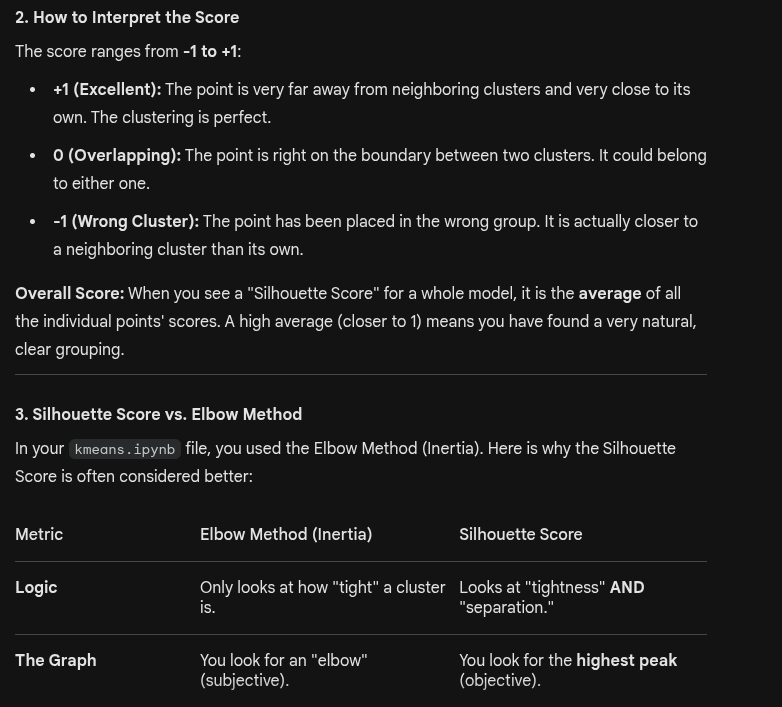

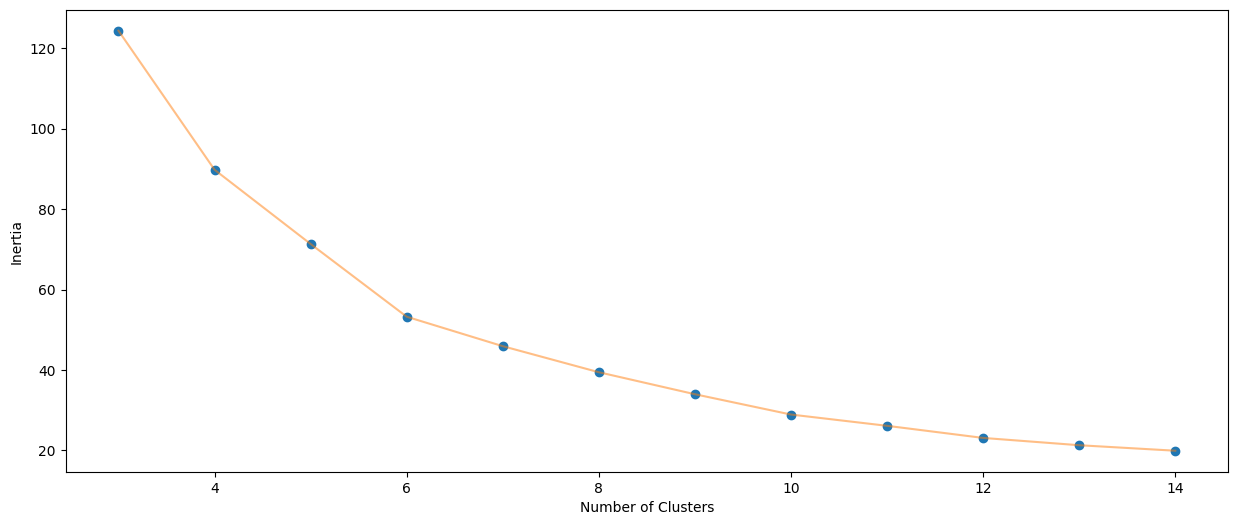

In [11]:
plt.figure(1 , figsize = (15 ,6))
plt.plot(k_range , inertia , 'o')
plt.plot(k_range , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

In [12]:
#choosing 4 as the optimal k
kmeans = (KMeans(n_clusters = 6 ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='lloyd') )
kmeans.fit(X1.values)
labels1 = kmeans.labels_
centroids1 = kmeans.cluster_centers_

In [13]:
# Convert X1 to a numpy array first to avoid the error
X_array = X1.values 

h = 0.02
# Now use X_array instead of X1
x_min, x_max = X_array[:, 0].min() - 1, X_array[:, 0].max() + 1
y_min, y_max = X_array[:, 1].min() - 1, X_array[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict the cluster for every point in the mesh grid
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

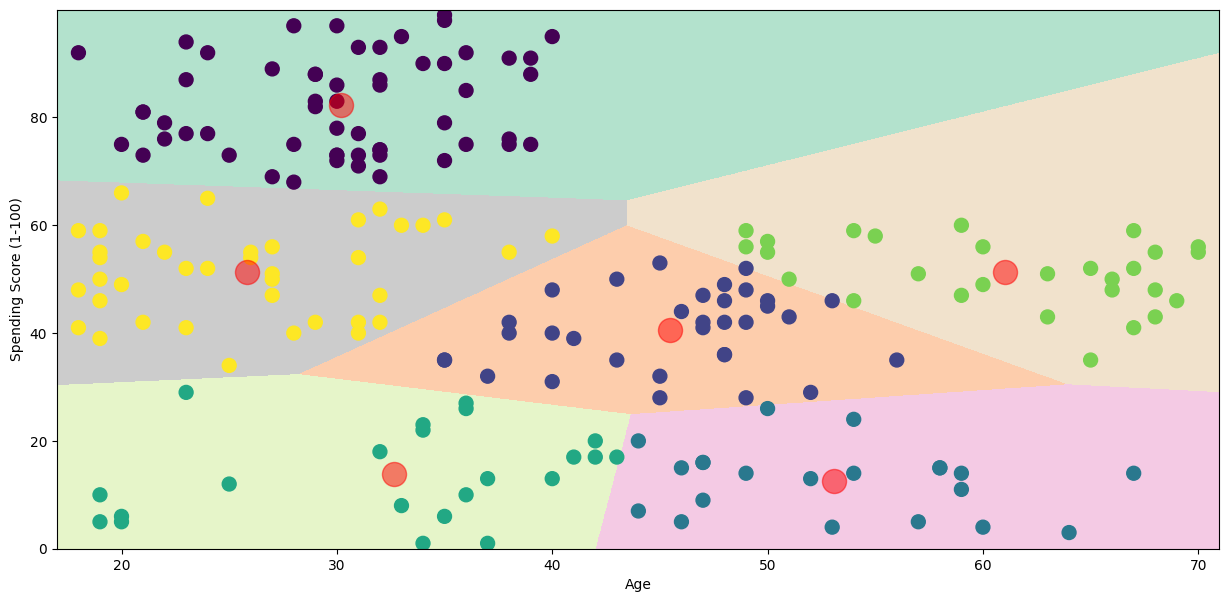

In [14]:
plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest', 
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Pastel2, aspect = 'auto', origin='lower')

plt.scatter( x = 'Age', y = 'Spending Score (1-100)', data = df, c = labels1, s = 100)
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Spending Score (1-100)') , plt.xlabel('Age')
plt.show()

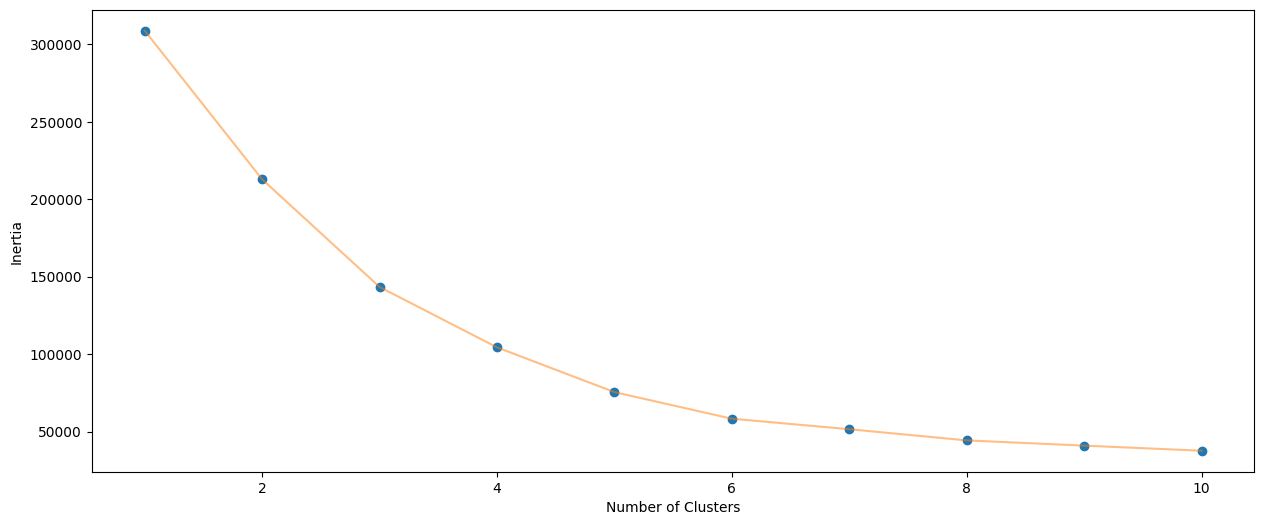

In [15]:
X3 = df[['Age' , 'Annual Income (k$)' ,'Spending Score (1-100)']].iloc[: , :].values
inertia = []
for n in range(1 , 11):
    algorithm = (KMeans(n_clusters = n, init='k-means++', n_init = 10, max_iter=300, 
                        tol=0.0001, random_state= 111, algorithm='lloyd'))
    algorithm.fit(X3)
    inertia.append(algorithm.inertia_)
plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 11) , inertia , 'o')
plt.plot(np.arange(1 , 11) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()